In [1]:
from volterra_collocation_solver import solve_VIE_1
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [10, 8]

In [2]:
# g_func = lambda t: t**2 + (1/6.0)*t**3
# kern_func = lambda x: 2 + x
# expected_soln = lambda t: t

g_func = lambda t: np.sin(t)
kern_func = lambda x: np.exp(x)
expected_soln = lambda t: np.cos(t) - np.sin(t)

g_noise = 0.0
kern_noise = 0.0

In [3]:
num_data_pts = 181
time_step = 0.1

# The possible collocation parameters are 0, 1/coll_divs, 2/coll_divs, ..., 1
coll_divs = 3

# This list indicates which of the possible collocation parameters we want
coll_choices = [1,2,3]

# Create Input Data

In [4]:
data_times = np.array([i*time_step for i in range(num_data_pts)])

kernel_data = np.array(
    [kern_func(x) + kern_noise * np.random.normal(0,1) for x in data_times])

g_data = np.array(
    [g_func(x) + g_noise * np.random.normal(0,1) for x in data_times])
g_data[0] = 0.0

# Call the Solver

In [5]:
%%time
sol_vals, soln_polys = solve_VIE_1(
    g_values=g_data,
    kernel_values=kernel_data,
    soln_init_value=expected_soln(data_times[0]),
    coll_divs=coll_divs,
    coll_choices=coll_choices,
    time_step=time_step,
    return_polys=True,
    force_continuous=False)

CPU times: user 1.53 s, sys: 674 ms, total: 2.2 s
Wall time: 416 ms


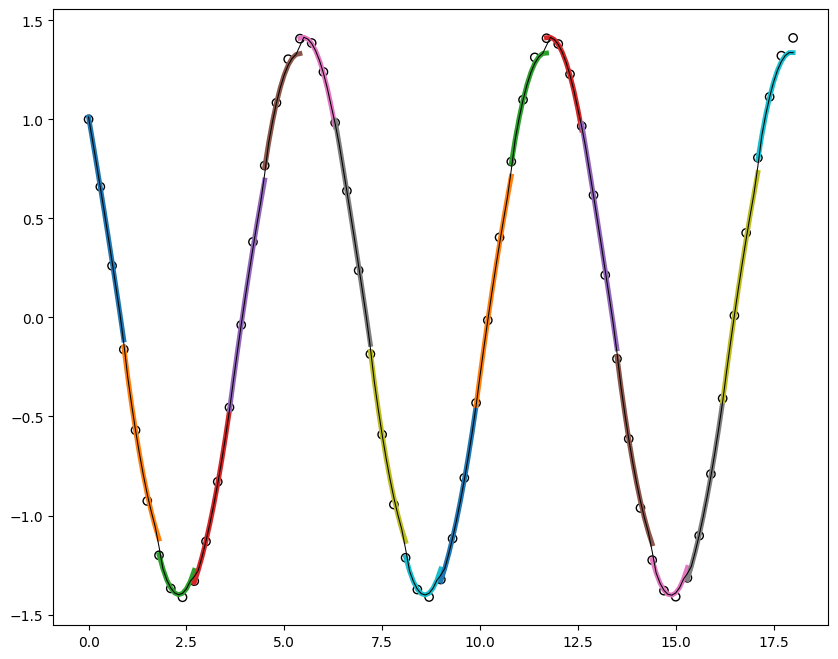

In [6]:
# Plot some of the values for the true solution
num_pts_to_plot = 50
skip = int(len(data_times) / num_pts_to_plot)
plt.scatter(data_times[::skip], [expected_soln(x) for x in data_times[::skip]],
            marker='o', facecolors='none', color="black");

# Draw the piecewise polynomials
for poly in soln_polys:
    times = np.linspace(poly.domain[0], poly.domain[1], coll_divs**2 + 1)
    values = [poly(t) for t in times]
    plt.plot(times, values, linewidth=3.5)

# Plot the returned solution values
plt.plot(data_times, sol_vals, color='black', linewidth=0.75);